# 📊 Unemployment Rate Analysis in India
> **Analyzing the impact of COVID-19 on India's unemployment rate using CMIE data**

---
Unemployment is measured by the **unemployment rate** — the number of people who are unemployed as a percentage of the total labour force. India saw a dramatic spike during the COVID-19 pandemic and subsequent lockdowns. This notebook explores regional trends, the pandemic's impact, and labour participation patterns.

**Datasets Used:**
- `Unemployment_in_India.csv` — Monthly state-level data with Rural/Urban breakdown (May 2019 – Dec 2020)
- `Unemployment_Rate_upto_11_2020.csv` — Monthly state-level data with geographic coordinates (Jan 2020 – Nov 2020)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


## 2. Load & Inspect Data

In [2]:
# Load datasets
df_geo   = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')
df_area  = pd.read_csv('Unemployment in India.csv')

# Standardize column names
df_geo.columns  = df_geo.columns.str.strip()
df_area.columns = df_area.columns.str.strip()

print("=== Geo Dataset (with coordinates) ===")
print(f"Shape: {df_geo.shape}")
df_geo.head()

=== Geo Dataset (with coordinates) ===
Shape: (267, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [3]:
print("=== Area Dataset (Rural / Urban breakdown) ===")
print(f"Shape: {df_area.shape}")
df_area.head()

=== Area Dataset (Rural / Urban breakdown) ===
Shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## 3. Data Cleaning & Preprocessing

In [4]:
# ── Geo dataset ──────────────────────────────────────────────────────────────
df_geo['Date'] = pd.to_datetime(df_geo['Date'].str.strip(), format='%d-%m-%Y')
df_geo.rename(columns={
    'Estimated Unemployment Rate (%)':        'Unemployment_Rate',
    'Estimated Employed':                     'Employed',
    'Estimated Labour Participation Rate (%)':'Labour_Participation_Rate',
    'Region.1':                               'Zone'
}, inplace=True)

# ── Area dataset ─────────────────────────────────────────────────────────────
df_area['Date'] = pd.to_datetime(df_area['Date'].str.strip(), format='%d-%m-%Y')
df_area.rename(columns={
    'Estimated Unemployment Rate (%)':        'Unemployment_Rate',
    'Estimated Employed':                     'Employed',
    'Estimated Labour Participation Rate (%)':'Labour_Participation_Rate'
}, inplace=True)

print("Missing values — Geo dataset:")
print(df_geo.isnull().sum())
print("\nMissing values — Area dataset:")
print(df_area.isnull().sum())

Missing values — Geo dataset:
Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Zone                         0
longitude                    0
latitude                     0
dtype: int64

Missing values — Area dataset:
Region                       28
Date                         28
Frequency                    28
Unemployment_Rate            28
Employed                     28
Labour_Participation_Rate    28
Area                         28
dtype: int64


In [5]:
# Drop rows with missing key values
df_geo.dropna(subset=['Unemployment_Rate', 'Employed'], inplace=True)
df_area.dropna(subset=['Unemployment_Rate', 'Employed'], inplace=True)

# Extract month/year for grouping
for df in [df_geo, df_area]:
    df['Month'] = df['Date'].dt.month
    df['Year']  = df['Date'].dt.year
    df['Month_Year'] = df['Date'].dt.to_period('M')

print("Date range (Geo): ",  df_geo['Date'].min().date(),  '→', df_geo['Date'].max().date())
print("Date range (Area):",  df_area['Date'].min().date(), '→', df_area['Date'].max().date())
print("\nCleaning complete ✅")

Date range (Geo):  2020-01-31 → 2020-10-31
Date range (Area): 2019-05-31 → 2020-06-30

Cleaning complete ✅


## 4. Descriptive Statistics

In [6]:
print("=== Geo Dataset — Key Statistics ===")
df_geo[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].describe().round(2)

=== Geo Dataset — Key Statistics ===


,Unemployment_Rate,Employed,Labour_Participation_Rate
count,267.00,267.00,267.00
mean,12.24,13962105.72,41.68
std,10.80,13366318.36,7.85
min,0.50,117542.00,16.77
25%,4.84,2838930.50,37.26
50%,9.65,9732417.00,40.39
75%,16.76,21878686.00,44.06
max,75.85,59433759.00,69.69


In [7]:
print("=== Area Dataset — Key Statistics ===")
df_area[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].describe().round(2)

=== Area Dataset — Key Statistics ===


,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740.00,740.00,740.00
mean,11.79,7204460.03,42.63
std,10.72,8087988.43,8.11
min,0.00,49420.00,13.33
25%,4.66,1190404.50,38.06
50%,8.35,4744178.50,41.16
75%,15.89,11275489.50,45.50
max,76.74,45777509.00,72.57


## 5. Nationwide Monthly Trend

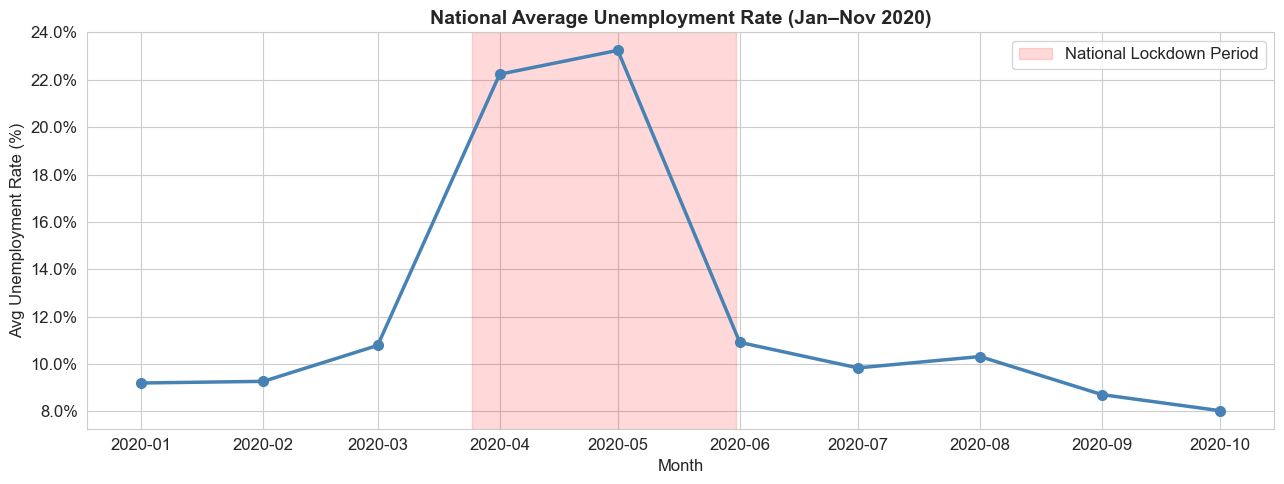

Peak month: 2020-05


In [8]:
monthly_avg = (
    df_geo.groupby('Month_Year')['Unemployment_Rate']
    .mean()
    .reset_index()
)
monthly_avg['Month_Year_dt'] = monthly_avg['Month_Year'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_avg['Month_Year_dt'], monthly_avg['Unemployment_Rate'],
        marker='o', linewidth=2.5, color='steelblue', markersize=7)

# Shade the COVID lockdown period (Mar–May 2020)
ax.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-05-31'),
           alpha=0.15, color='red', label='National Lockdown Period')

ax.set_title('National Average Unemployment Rate (Jan–Nov 2020)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Unemployment Rate (%)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.savefig('plot_national_trend.png', dpi=150)
plt.show()
print("Peak month:", monthly_avg.loc[monthly_avg['Unemployment_Rate'].idxmax(), 'Month_Year'])

## 6. State-wise Average Unemployment Rate

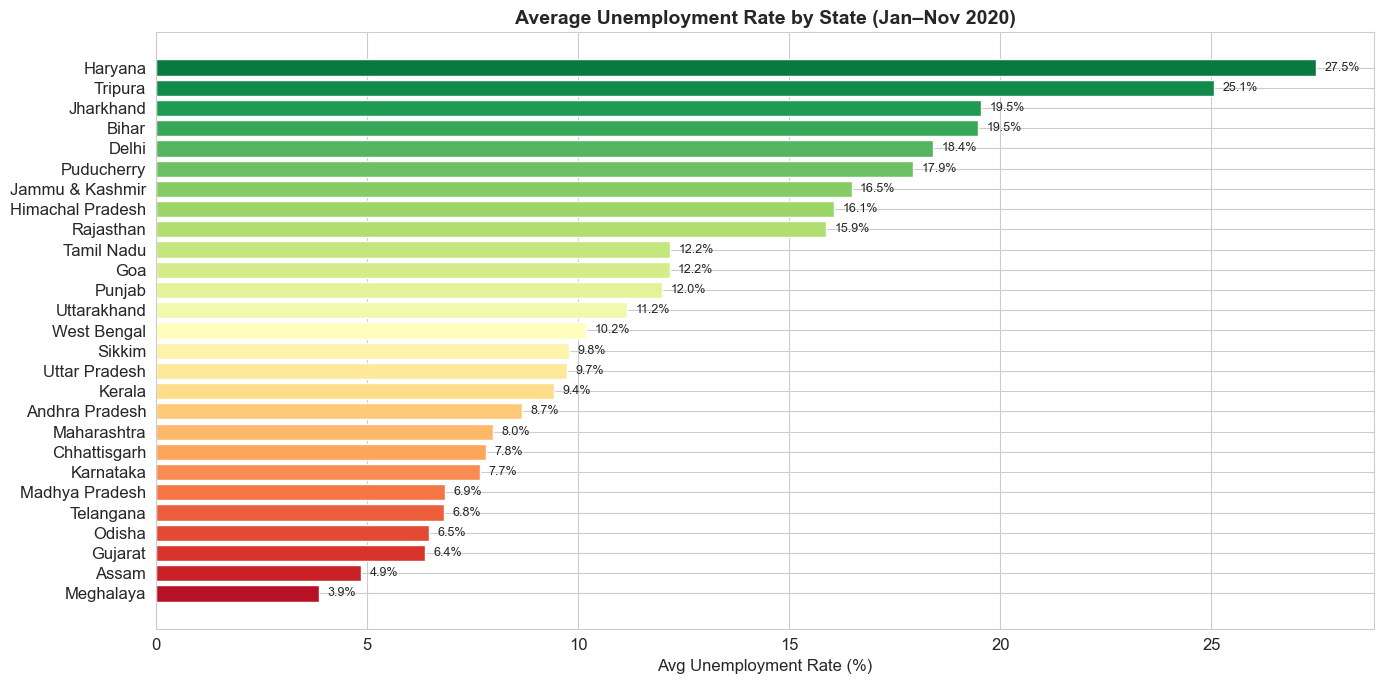

In [9]:
state_avg = (
    df_geo.groupby('Region')['Unemployment_Rate']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(state_avg['Region'], state_avg['Unemployment_Rate'],
               color=sns.color_palette('RdYlGn_r', len(state_avg)))

for bar, val in zip(bars, state_avg['Unemployment_Rate']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_title('Average Unemployment Rate by State (Jan–Nov 2020)', fontsize=14, fontweight='bold')
ax.set_xlabel('Avg Unemployment Rate (%)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('plot_statewise.png', dpi=150)
plt.show()

## 7. COVID Impact — Before vs During Lockdown

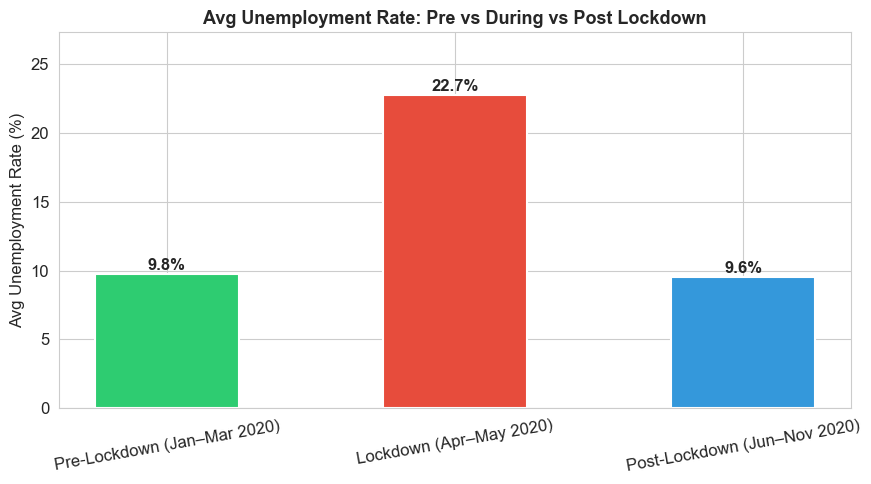


COVID Spike Factor: 2.33 x


In [10]:
df_geo['Period'] = df_geo['Date'].apply(
    lambda d: 'Lockdown (Apr–May 2020)' if (d.year == 2020 and d.month in [4, 5])
    else ('Pre-Lockdown (Jan–Mar 2020)' if (d.year == 2020 and d.month <= 3)
    else 'Post-Lockdown (Jun–Nov 2020)')
)

period_avg = (
    df_geo.groupby('Period')['Unemployment_Rate']
    .mean()
    .reindex(['Pre-Lockdown (Jan–Mar 2020)', 'Lockdown (Apr–May 2020)', 'Post-Lockdown (Jun–Nov 2020)'])
)

colors = ['#2ecc71', '#e74c3c', '#3498db']
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(period_avg.index, period_avg.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, period_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

ax.set_title('Avg Unemployment Rate: Pre vs During vs Post Lockdown', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Unemployment Rate (%)')
ax.set_ylim(0, period_avg.max() * 1.2)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('plot_covid_impact.png', dpi=150)
plt.show()

print("\nCOVID Spike Factor:", round(period_avg['Lockdown (Apr–May 2020)'] / period_avg['Pre-Lockdown (Jan–Mar 2020)'], 2), "x")

## 8. Rural vs Urban Unemployment

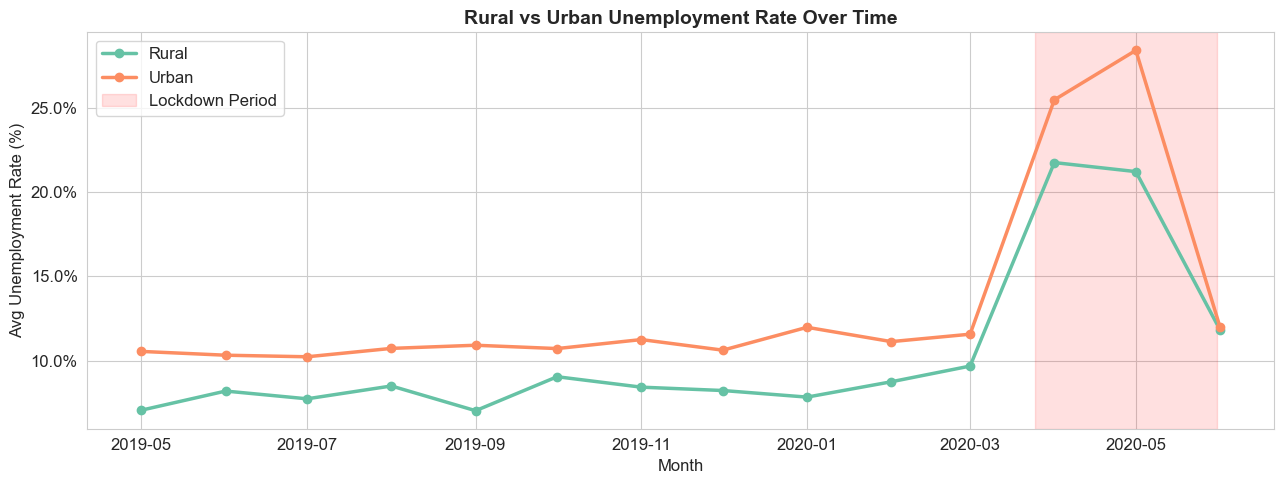

In [11]:
area_monthly = (
    df_area.groupby(['Month_Year', 'Area'])['Unemployment_Rate']
    .mean()
    .reset_index()
)
area_monthly['Date'] = area_monthly['Month_Year'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))
for area, grp in area_monthly.groupby('Area'):
    ax.plot(grp['Date'], grp['Unemployment_Rate'], marker='o', linewidth=2.5, label=area)

ax.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-05-31'),
           alpha=0.12, color='red', label='Lockdown Period')
ax.set_title('Rural vs Urban Unemployment Rate Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Unemployment Rate (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend()
plt.tight_layout()
plt.savefig('plot_rural_urban.png', dpi=150)
plt.show()

## 9. Zone-wise Heatmap (Region × Month)

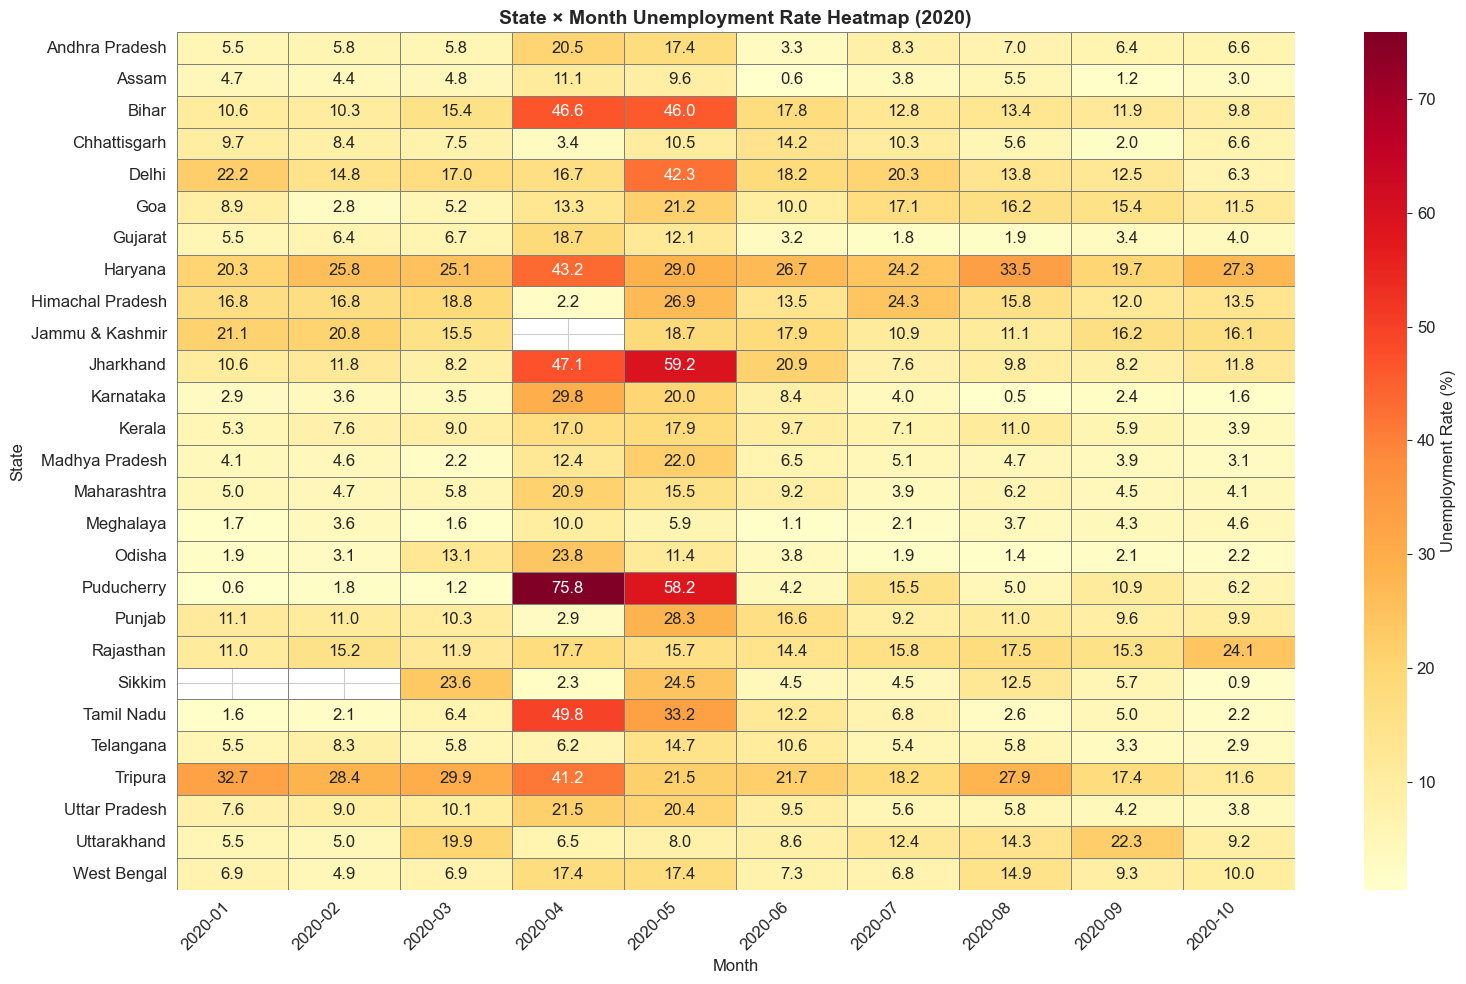

In [12]:
pivot = df_geo.pivot_table(
    index='Region',
    columns='Month_Year',
    values='Unemployment_Rate',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.5, linecolor='grey',
            cbar_kws={'label': 'Unemployment Rate (%)'},
            ax=ax)
ax.set_title('State × Month Unemployment Rate Heatmap (2020)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_heatmap.png', dpi=150)
plt.show()

## 10. Labour Participation Rate vs Unemployment Rate

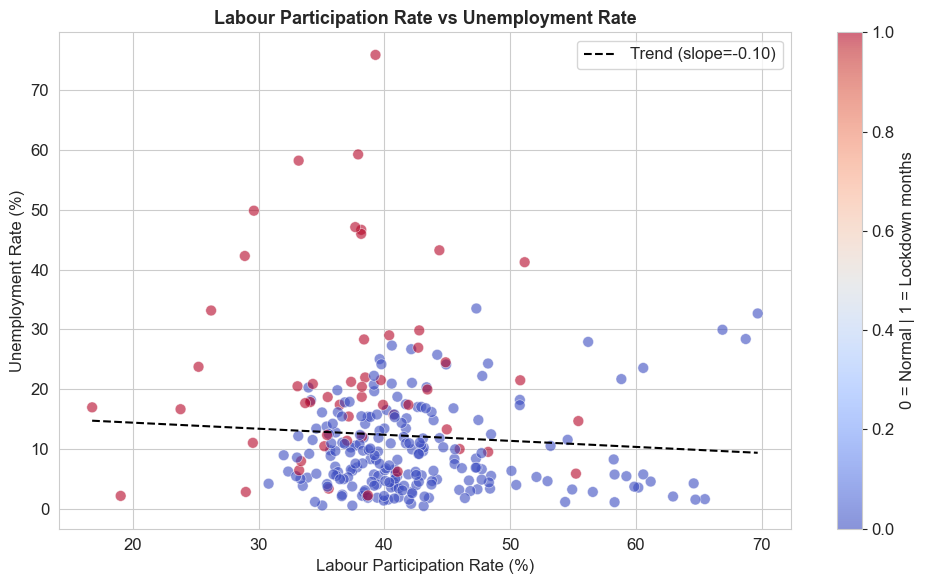

Pearson correlation (LPR vs Unemployment): -0.074


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    df_geo['Labour_Participation_Rate'],
    df_geo['Unemployment_Rate'],
    c=df_geo['Date'].apply(lambda d: 1 if d.month in [4, 5] else 0),
    cmap='coolwarm', alpha=0.6, s=60, edgecolors='white', linewidths=0.5
)
plt.colorbar(scatter, ax=ax, label='0 = Normal | 1 = Lockdown months')
ax.set_xlabel('Labour Participation Rate (%)')
ax.set_ylabel('Unemployment Rate (%)')
ax.set_title('Labour Participation Rate vs Unemployment Rate', fontsize=13, fontweight='bold')

# Regression line
m, b = np.polyfit(df_geo['Labour_Participation_Rate'], df_geo['Unemployment_Rate'], 1)
x_line = np.linspace(df_geo['Labour_Participation_Rate'].min(), df_geo['Labour_Participation_Rate'].max(), 100)
ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.5, label=f'Trend (slope={m:.2f})')
ax.legend()
plt.tight_layout()
plt.savefig('plot_scatter.png', dpi=150)
plt.show()

corr = df_geo['Labour_Participation_Rate'].corr(df_geo['Unemployment_Rate'])
print(f"Pearson correlation (LPR vs Unemployment): {corr:.3f}")

## 11. Top 5 Most & Least Affected States During Lockdown

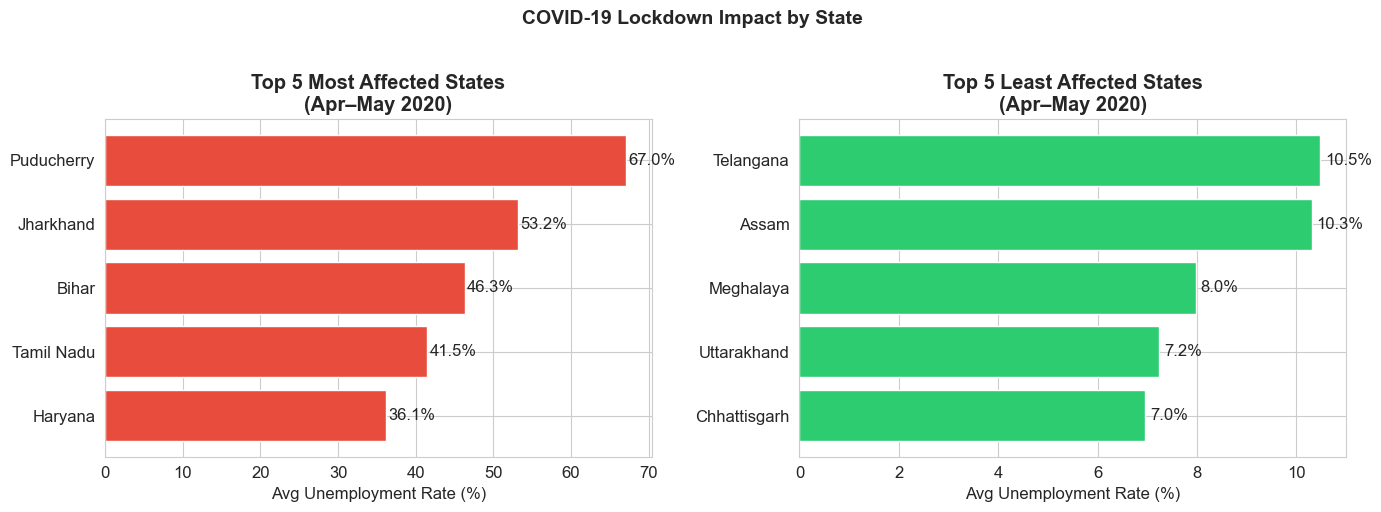

In [14]:
lockdown_df = df_geo[df_geo['Date'].dt.month.isin([4, 5])]
lockdown_state = lockdown_df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)

top5    = lockdown_state.head(5)
bottom5 = lockdown_state.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top5.index[::-1], top5.values[::-1], color='#e74c3c')
axes[0].set_title('Top 5 Most Affected States\n(Apr–May 2020)', fontweight='bold')
axes[0].set_xlabel('Avg Unemployment Rate (%)')
for i, v in enumerate(top5.values[::-1]):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center')

axes[1].barh(bottom5.index[::-1], bottom5.values[::-1], color='#2ecc71')
axes[1].set_title('Top 5 Least Affected States\n(Apr–May 2020)', fontweight='bold')
axes[1].set_xlabel('Avg Unemployment Rate (%)')
for i, v in enumerate(bottom5.values[::-1]):
    axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center')

plt.suptitle('COVID-19 Lockdown Impact by State', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_top_bottom.png', dpi=150)
plt.show()

## 12. Correlation Matrix

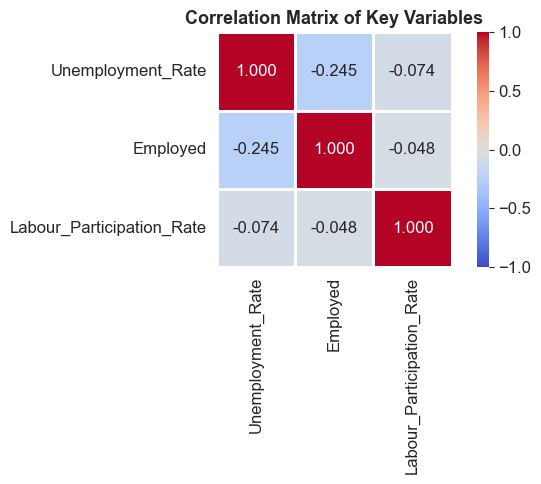

In [15]:
corr_cols = ['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']
corr_matrix = df_geo[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=1, ax=ax)
ax.set_title('Correlation Matrix of Key Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_corr.png', dpi=150)
plt.show()

## 13. Monthly Distribution — Boxplot

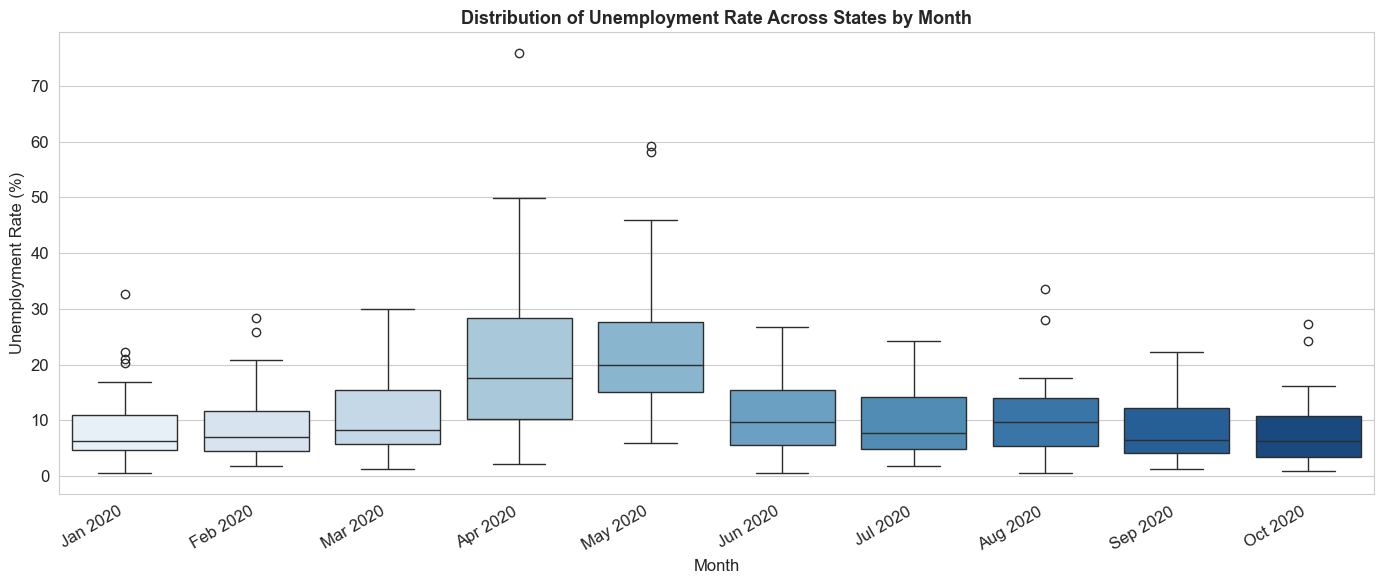

In [16]:
df_geo['Month_Label'] = df_geo['Date'].dt.strftime('%b %Y')
month_order = df_geo.sort_values('Date')['Month_Label'].unique()

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_geo, x='Month_Label', y='Unemployment_Rate',
            order=month_order, palette='Blues', ax=ax)
ax.set_title('Distribution of Unemployment Rate Across States by Month', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Unemployment Rate (%)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('plot_boxplot.png', dpi=150)
plt.show()

## 14. Key Insights & Conclusion

In [17]:
pre_lock  = df_geo[df_geo['Date'].dt.month <= 3]['Unemployment_Rate'].mean()
lock      = df_geo[df_geo['Date'].dt.month.isin([4,5])]['Unemployment_Rate'].mean()
post_lock = df_geo[df_geo['Date'].dt.month >= 6]['Unemployment_Rate'].mean()

print("="*55)
print("       KEY FINDINGS — INDIA UNEMPLOYMENT ANALYSIS")
print("="*55)
print(f"  📌 Pre-Lockdown  Avg Unemployment :  {pre_lock:.2f}%")
print(f"  🔴 Lockdown      Avg Unemployment :  {lock:.2f}%   ← PEAK")
print(f"  🟢 Post-Lockdown Avg Unemployment :  {post_lock:.2f}%")
print(f"  📈 COVID Spike Factor             :  {lock/pre_lock:.1f}x")
print()
print(f"  🏆 Most  Affected State (lockdown): {lockdown_state.idxmax()}")
print(f"  ✅ Least Affected State (lockdown): {lockdown_state.idxmin()}")
print()
print("  📝 Observations:")
print("  - Urban unemployment surged more sharply than rural")
print("    during lockdown months (Apr–May 2020).")
print("  - Labour participation rate dropped in tandem,")
print("    indicating discouraged worker effect.")
print("  - Recovery was visible by Jun–Jul 2020, but")
print("    rates remained elevated above pre-COVID levels.")
print("="*55)

       KEY FINDINGS — INDIA UNEMPLOYMENT ANALYSIS
  📌 Pre-Lockdown  Avg Unemployment :  9.76%
  🔴 Lockdown      Avg Unemployment :  22.75%   ← PEAK
  🟢 Post-Lockdown Avg Unemployment :  9.56%
  📈 COVID Spike Factor             :  2.3x

  🏆 Most  Affected State (lockdown): Puducherry
  ✅ Least Affected State (lockdown): Chhattisgarh

  📝 Observations:
  - Urban unemployment surged more sharply than rural
    during lockdown months (Apr–May 2020).
  - Labour participation rate dropped in tandem,
    indicating discouraged worker effect.
  - Recovery was visible by Jun–Jul 2020, but
    rates remained elevated above pre-COVID levels.
